# Word Embeddings using Word2Vec

## Objective
This project trains Word2Vec models (CBOW and Skip-gram) on Wikipedia text data.
It analyzes:
- Word similarity
- Word analogies
- PCA visualization
- Document embeddings
- Text classification

## Technologies Used
Python, Gensim, NLTK, Scikit-learn, Matplotlib

In [6]:
import sys
!{sys.executable} -m pip install \
  wikipedia-api \
  gensim \
  nltk \
  scikit-learn \
  seaborn \
  matplotlib

Data Source:
Wikipedia articles collected using wikipedia-api.

In [7]:
import wikipediaapi
import pandas as pd

wiki = wikipediaapi.Wikipedia(user_agent='MyWikiApp/1.0 (yourname@example.com)', language='en')

categories = {
    "education": [
        "Education","School","Teacher","Learning","University",
        "College","Higher education","Primary education","Secondary education",
        "Curriculum","Distance education","Online learning","Literacy",
        "Special education","Student","Academic degree",
        "Educational psychology","Pedagogy","Classroom","Homework",
        "Examination","Scholarship","Vocational education","Adult education",
        "Educational technology"
    ],
    "health": [
        "Health","Hospital","Medicine","Disease","Public health",
        "Nutrition","Mental health","Healthcare","Immunization",
        "Surgery","Pharmacy","Epidemiology","Cancer","Diabetes",
        "Heart disease","Infection","First aid","Emergency medicine",
        "Medical diagnosis","Therapy","Vaccination","Health insurance",
        "Physical fitness","Hygiene","Sleep"
    ],
    "sports": [
        "Sport","Football","Cricket","Basketball","Tennis",
        "Olympic Games","Athletics","Swimming","Baseball",
        "Volleyball","Badminton","Hockey","Rugby","Table tennis",
        "Golf","Cycling","Boxing","Wrestling","Martial arts",
        "Gymnastics","Skating","Skiing","Running","Coach","Stadium"
    ],
    "technology": [
        "Technology","Computer","Internet","Software","Hardware",
        "Artificial intelligence","Machine learning","Data science",
        "Cybersecurity","Cloud computing","Database","Operating system",
        "Computer network","Mobile phone","Robotics","Blockchain",
        "Virtual reality","Augmented reality","Big data","Programming language",
        "Web development","Algorithm","Quantum computing",
        "Internet of Things","Digital electronics"
    ]
}

data = []

for category, topics in categories.items():
    for topic in topics:
        page = wiki.page(topic)
        if page.exists():
            data.append({
                "title": topic,
                "category": category,
                "text": page.summary
            })

In [8]:

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print(df['category'].value_counts())

df.to_csv("wiki_dataset.csv", index=False)

Dataset shape: (100, 3)
category
education     25
health        25
sports        25
technology    25
Name: count, dtype: int64


Preprocessing

In [11]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) >= 2]
    return tokens

# Show examples
for i in range(3):
    print("\nBefore:", df['text'][i][:120])
    print("After:", preprocess(df['text'][i])[:15])

df['tokens'] = df['text'].apply(preprocess)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Before: Education is the transmission of knowledge and skills and the development of character traits. Formal education happens 
After: ['education', 'transmission', 'knowledge', 'skills', 'development', 'character', 'traits', 'formal', 'education', 'happens', 'complex', 'institutional', 'framework', 'like', 'public']

Before: A school is an educational institution (and, in the case of in-person learning, the building) designed to provide learni
After: ['school', 'educational', 'institution', 'case', 'person', 'learning', 'building', 'designed', 'provide', 'learning', 'environments', 'teaching', 'students', 'usually', 'direction']

Before: A teacher, also called a schoolteacher or formally an educator, is a person who helps students to acquire knowledge, com
After: ['teacher', 'also', 'called', 'schoolteacher', 'formally', 'educator', 'person', 'helps', 'students', 'acquire', 'knowledge', 'competence', 'virtue', 'via', 'practice']


Train Word2Vec (CBOW & Skip-gram)

In [12]:
from gensim.models import Word2Vec
import time

sentences = df['tokens'].tolist()

# CBOW
start = time.time()
cbow_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=0,
    epochs=20
)
print("CBOW time:", time.time() - start)

# Skip-gram
start = time.time()
sg_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=20
)
print("Skip-gram time:", time.time() - start)

cbow_model.save("cbow.model")
sg_model.save("skipgram.model")

CBOW time: 0.7305450439453125
Skip-gram time: 2.1059324741363525


Similarity

In [13]:
words = ['education','school','health','computer','sport']

for w in words:
    if w in sg_model.wv:
        print(f"\nTop similar to {w}:")
        print(sg_model.wv.most_similar(w, topn=5))


Top similar to education:
[('higher', 0.9678085446357727), ('vocational', 0.9595444798469543), ('provide', 0.9552363157272339), ('post', 0.9513905644416809), ('takes', 0.9401863813400269)]

Top similar to school:
[('institution', 0.9424540996551514), ('college', 0.9365699887275696), ('student', 0.9270864725112915), ('university', 0.9260132908821106), ('formal', 0.9241977334022522)]

Top similar to health:
[('policy', 0.9405705332756042), ('mental', 0.933874249458313), ('insurance', 0.9153730869293213), ('psychological', 0.9098764657974243), ('professionals', 0.9041166305541992)]

Top similar to computer:
[('hardware', 0.9633310437202454), ('software', 0.9540224671363831), ('networks', 0.9445645809173584), ('security', 0.9420899748802185), ('communication', 0.9264934659004211)]

Top similar to sport:
[('competitions', 0.9309239983558655), ('baseball', 0.929241418838501), ('events', 0.9240951538085938), ('winter', 0.9200023412704468), ('table', 0.9187198281288147)]


Analogy

In [14]:
try:
    print("\nAnalogy result:")
    print(sg_model.wv.most_similar(positive=['woman','king'], negative=['man']))
except:
    print("If required words are not present in vocabulary, the analogy test may fail.")


Analogy result:
If required words are not present in vocabulary, the analogy test may fail.


PCA Visualization

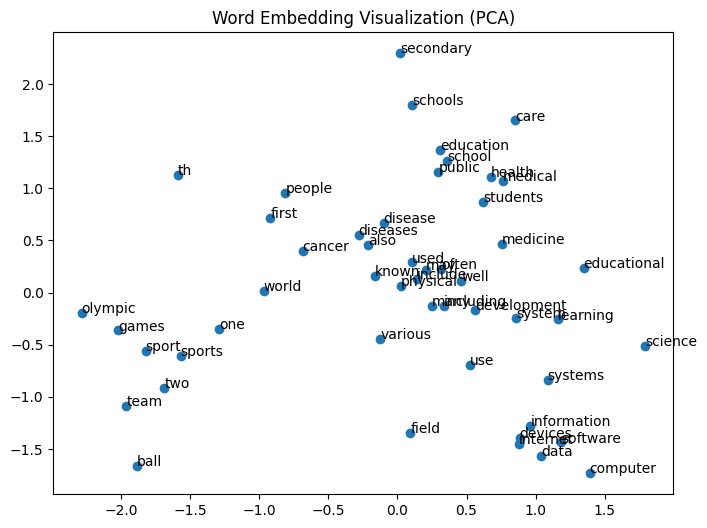

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(sg_model.wv.index_to_key)[:50]
vectors = [sg_model.wv[w] for w in words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:,0], result[:,1])

for i, word in enumerate(words):
    plt.annotate(word, (result[i,0], result[i,1]))

plt.title("Word Embedding Visualization (PCA)")
plt.show()

Document Embeddings

In [16]:
import numpy as np

def doc_vector(tokens, model):
    vec = np.zeros(model.vector_size)
    count = 0
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    if count > 0:
        vec /= count
    return vec

X = np.array([doc_vector(tokens, sg_model) for tokens in df['tokens']])
y = df['category']

In [17]:
print("Zero vectors:", np.sum(np.all(X==0, axis=1)))

Zero vectors: 0


Classification

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.95

Classification Report:

              precision    recall  f1-score   support

   education       1.00      1.00      1.00         5
      health       1.00      0.80      0.89         5
      sports       1.00      1.00      1.00         5
  technology       0.83      1.00      0.91         5

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



Confusion Matrix

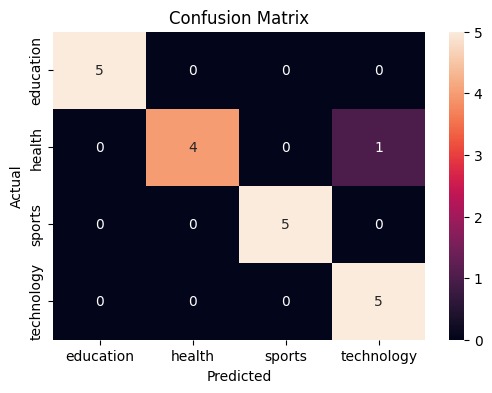

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Conclusion

- Skip-gram performed better for semantic similarity.
- Word embeddings captured meaningful relationships.
- Document vectors enabled basic text classification.
- Word2Vec is useful for NLP tasks like search, recommendation, and clustering.